## **Tập dữ liệu (CIFAR-10)**

### **1. Giới thiệu về tập dữ liệu**

**CIFAR-10** là một tập dữ liệu phổ biến trong lĩnh vực thị giác máy tính, bao gồm:
- 60,000 ảnh màu kích thước 32 × 32
- Chia thành:
  - 50,000 ảnh train
  - 10,000 ảnh test
  - 10 lớp đối tượng: Máy bay, ô tô, chim, mèo, hươu, chó, ếch, ngựa, tàu, xe tải


Đây là tập dữ liệu có độ khó trung bình do:
- Ảnh có màu (3 kênh RGB)
- Đối tượng đa dạng, nhiều nhiễu nền
- Không đơn giản như MNIST nhưng cũng không quá lớn như ImageNet

100%|██████████| 170M/170M [00:03<00:00, 49.5MB/s]


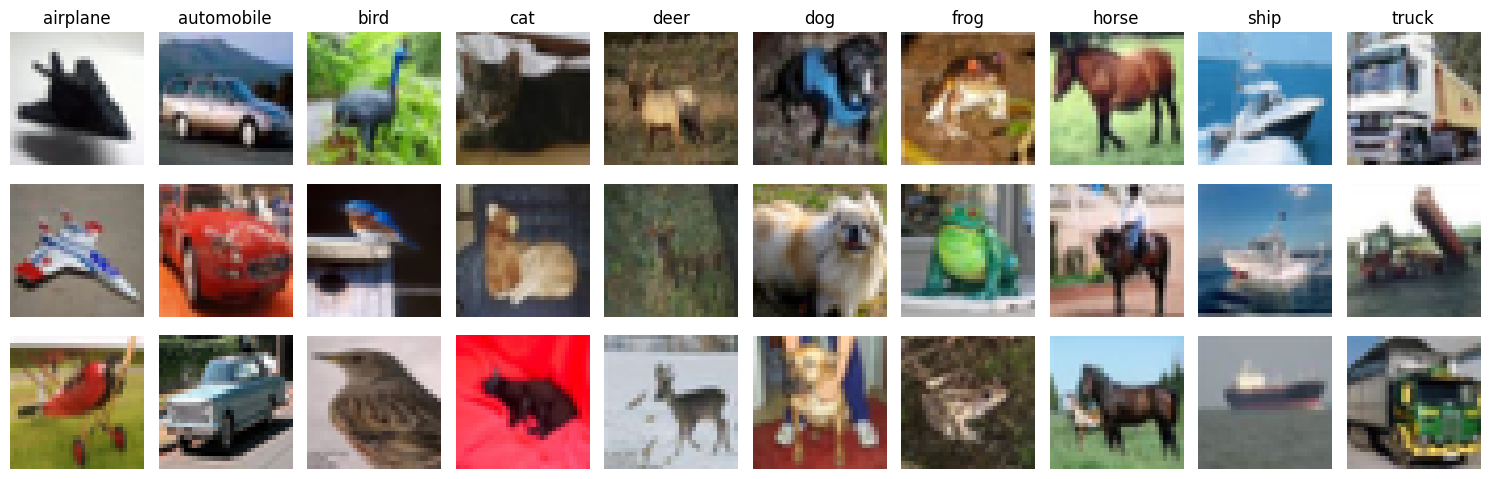

In [1]:
import matplotlib.pyplot as plt
from torchvision import datasets

# Load dataset (không transform)
dataset = datasets.CIFAR10(root='./data', train=True, download=True)

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Lưu 3 ảnh cho mỗi class
samples = {i: [] for i in range(10)}

# Duyệt dataset để lấy đủ 3 ảnh mỗi class
for img, label in dataset:
    if len(samples[label]) < 3:
        samples[label].append(img)

    # kiểm tra đủ chưa
    if all(len(v) == 3 for v in samples.values()):
        break

# Plot 3x10
plt.figure(figsize=(15, 5))

for col in range(10):        # 10 class (cột)
    for row in range(3):     # 3 ảnh (hàng)
        plt.subplot(3, 10, row * 10 + col + 1)
        plt.imshow(samples[col][row])

        if row == 0:
            plt.title(classes[col])

        plt.axis('off')

plt.tight_layout()
plt.show()

### **2. Lí do lựa chọn**

**Phù hợp với mục tiêu môn học**
- Bài tập yêu cầu so sánh nhiều mô hình: từ Softmax → MLP → CNN → ViT → RNN
- CIFAR-10 đủ phức tạp để:
  - Thể hiện rõ sự khác biệt giữa các mô hình
  - Đánh giá hiệu quả học đặc trưng (feature learning)


**Kích thước nhỏ, dễ huấn luyện**
- Ảnh chỉ 32x32 → chi phí tính toán thấp
- Phù hợp để:
  - Tự viết training loop
  - Thử nghiệm nhiều kiến trúc trong thời gian ngắn

**Benchmark phổ biến**
- Được sử dụng rộng rãi trong nghiên cứu
- Có nhiều kết quả tham chiếu để so sánh
- Giúp đánh giá mô hình một cách khách quan

Tóm lại: CIFAR-10 là tập dữ liệu cân bằng giữa độ phức tạp và chi phí tính toán, phù hợp để triển khai và so sánh đa dạng các kiến trúc học sâu trong bài toán phân loại ảnh.

## **Phần 1 — Xây dựng các mô hình phân loại**

### **1. Softmax Regression**

In [2]:
import torch
import torch.nn as nn

class SoftmaxModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(32*32*3, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

Mô hình thuộc loại linear classifier đơn giản, không có hidden layer, bao gồm:
- **Input layer**: vector hoá ảnh kích thước 32x32x3 = 3072
- **Fully Connected Layer** (nn.Linear): ánh xạ từ 3072 → num_classes (số lượng class)

Luồng xử lý (Forward pass):
- **Flatten input**: ảnh đầu vào dạng (batch_size, 3, 32, 32) → reshape thành (batch_size, 3072)
- **Linear transformation**: biến đổi tuyến tính:

$$
y = Wx + b
$$

Trong đó:

$$
W \in \mathbb{R}^{\text{num_classes} \times 3072}
$$

$$
b \in \mathbb{R}^{\text{num_classes}}
$$

Output:
- Trả về **logits** (raw scores cho từng class)
- **Softmax** sẽ được áp dụng trong loss

### **2. Multi-Layer Perceptron**

In [3]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

**Kiến trúc tổng thể**
- Mô hình thuộc loại feedforward neural network (fully connected)
- Bao gồm nhiều tầng tuyến tính và hàm kích hoạt phi tuyến
- Cấu trúc cụ thể:
  - Input: 32x32x3=3072
  - Hidden layer 1: 512 neurons + ReLU
  - Hidden layer 2: 256 neurons + ReLU
  - Output layer: num_classes

**Luồng xử lý (Forward pass)**
- Flatten input: ảnh (batch_size, 3, 32, 32) → (batch_size, 3072)
- Feedforward qua các tầng:
  - Tầng 1:
$$
h_1 = \mathrm{ReLU}(W_1 x + b_1)
$$
  - Tầng 2:
$$
h_2 = \mathrm{ReLU}(W_2 h_1 + b_2)
$$

  - Output:
$$
y = W_3 h_2 + b_3
$$

**Output**
- Trả về logits
- Softmax được áp dụng trong hàm loss (CrossEntropyLoss)

## **3. Mô hình CNN-based**

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8 -> 4
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # avoid overfitting
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

**Kiến trúc tổng thể**

- Mô hình thuộc loại Convolutional Neural Network (CNN)
Bao gồm các tầng tích chập (Convolution), chuẩn hoá (BatchNorm), hàm kích hoạt phi tuyến (ReLU), pooling và fully connected.

- Cấu trúc cụ thể
  - **Input** (3 x 32 x 32) (ảnh màu CIFAR-10)
  - **Feature Extractor** (Convolutional blocks):
    - **Block 1**:
      - Conv2d(3 → 64, kernel=3, padding=1)
      - BatchNorm
      - ReLU
      - Conv2d(64 → 64, kernel=3, padding=1)
      - BatchNorm
      - ReLU
      - MaxPool2d(2) → giảm kích thước: 32 → 16
    - **Block 2**:
      - Conv2d(64 → 128, kernel=3, padding=1)
      - BatchNorm
      - ReLU
      - Conv2d(128 → 128, kernel=3, padding=1)
      - BatchNorm
      - ReLU
      - MaxPool2d(2) → giảm kích thước: 16 → 8
    - **Block 3**:
      - Conv2d(128 → 256, kernel=3, padding=1)
      - BatchNorm
      - ReLU
      - MaxPool2d(2) → giảm kích thước: 8 → 4 (Output feature map: 256 x 4 x 4)
  - **Classifier** (Fully Connected):
    - Flatten: 256 x 4 x 4 = 4096
    - Linear(4096 → 512) + ReLU
    - Dropout(0.5)
    - Linear(512 → num_classes)

**Luồng xử lý (Forward pass)**
- Feature extraction
- Flatten
- Fully connected

**Output**
- Trả về **logits**
- **Softmax** được áp dụng trong hàm loss (CrossEntropyLoss)

## **4. Mô hình ViT-based**

In [5]:
import torch
import torch.nn as nn

class ViTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        num_classes=10,
        dim=128,
        depth=6,
        heads=8,
        mlp_dim=256,
        dropout=0.1
    ):
        super().__init__()

        num_patches = (img_size // patch_size) ** 2

        # Patch embedding
        self.patch_embed = nn.Conv2d(
            3, dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # Positional embedding
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, dim)
        )

        self.dropout = nn.Dropout(dropout)

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        # Classifier
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)  # (B, dim, H, W)
        x = x.flatten(2).transpose(1, 2)  # (B, N, dim)

        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # Add position
        x = x + self.pos_embedding
        x = self.dropout(x)

        # Transformer
        x = self.transformer(x)

        # Take CLS token
        x = x[:, 0]

        return self.mlp_head(x)

**Kiến trúc tổng thể**

- Mô hình thuộc loại Vision Transformer (ViT), bao gồm các bước chia ảnh thành patch, embedding, Transformer Encoder và fully connected classifier.
- Cấu trúc cụ thể:
  - Input: (3 x 32 x 32) (ảnh màu CIFAR-10)
  - Patch Embedding:
    - Chia ảnh thành các patch kích thước (4 x 4)
    - Sử dụng Conv2d(3 → dim, kernel=4, stride=4)
    - Số patch $N = (32/4)^2 = 64$
    - Output: (batch_size, 64, dim)
  - CLS Token:
    - Thêm 1 vector học được vào đầu chuỗi
    - Kích thước sau khi thêm: (batch_size, 65, dim)
  - Positional Embedding:
    - Cộng embedding vị trí vào từng patch
    - Giữ nguyên kích thước: (batch_size, 65, dim)
  - Transformer Encoder:
    - Gồm 6 layers
    - Mỗi layer bao gồm:
      - Multi-head Self-Attention (heads = 8)
      - Feed Forward (dim → 256 → dim)
      - LayerNorm + Residual connection
    - Output: (batch_size, 65, dim)
  - Classifier:
    - Lấy vector tại vị trí CLS token: (batch_size, dim)
    - LayerNorm
    - Linear(dim → num_classes)

**Luồng xử lý (Forward pass)**

- Patch embedding
- Thêm CLS token
- Cộng positional embedding
- Transformer encoding
- Lấy CLS token
- Fully connected

**Output**
- Trả về **logits**
- **Softmax** được áp dụng trong hàm loss (CrossEntropyLoss)

## **Phần 2 — Huấn luyện, đánh giá và so sánh**

### **1. Training Pipeline**

In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
SAVE_DIR = "/content/drive/MyDrive/models"
os.makedirs(SAVE_DIR, exist_ok=True)

def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision = precision_score(all_labels, all_preds, average='macro')
    recall    = recall_score(all_labels, all_preds, average='macro')
    f1        = f1_score(all_labels, all_preds, average='macro')

    cm = confusion_matrix(all_labels, all_preds)

    acc = np.mean(np.array(all_preds) == np.array(all_labels))

    return acc, precision, recall, f1, cm


def train(model, name, train_loader, val_loader, epochs=5, lr=1e-3):
    model.to(device)

    criterion = nn.CrossEntropyLoss() # include softmax
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {
        "loss": [],
        "acc": [],
        "f1": []
    }

    best_f1 = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        acc, precision, recall, f1, cm = evaluate(model, val_loader)

        history["loss"].append(avg_loss)
        history["acc"].append(acc)
        history["f1"].append(f1)

        print(f"{name} | Epoch {epoch+1}: Loss={avg_loss:.4f}, Acc={acc:.4f}, F1={f1:.4f}")

        # ===== SAVE BEST =====
        if f1 > best_f1:
            best_f1 = f1
            save_path = f"{SAVE_DIR}/{name}_best.pth"
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model to {save_path}")

    return history, cm

Mounted at /content/drive
cuda


In [7]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ===== 2. Transform =====
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# ===== 3. Dataset =====

full_train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=augment_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# ===== Split train -> train + val =====
train_size = int(0.8 * len(full_train_dataset))  # 80%
val_size   = len(full_train_dataset) - train_size  # 20%

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

# ===== DataLoader =====
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

num_classes = 10

models = {
    "Softmax": SoftmaxModel(),
    "MLP": MLP(),
    "CNN": CNN(),
    "ViT": ViTransformer()
}

results = []
conf_matrices = {}
histories = {}

for name, model in models.items():
    print(f"\n===== Training {name} =====")

    history, cm = train(model, name, train_loader, val_loader, epochs=20, lr=1e-3)
    histories[name] = history # save history

    print(f"\n===== Testing {name} =====")

    acc, precision, recall, f1, cm_test = evaluate(model, test_loader)
    conf_matrices[name] = cm_test

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    conf_matrices[name] = cm


===== Training Softmax =====
Softmax | Epoch 1: Loss=1.8687, Acc=0.3849, F1=0.3772
Saved best model to /content/drive/MyDrive/models/Softmax_best.pth
Softmax | Epoch 2: Loss=1.7941, Acc=0.3869, F1=0.3851
Saved best model to /content/drive/MyDrive/models/Softmax_best.pth
Softmax | Epoch 3: Loss=1.7759, Acc=0.3802, F1=0.3755
Softmax | Epoch 4: Loss=1.7712, Acc=0.3816, F1=0.3767
Softmax | Epoch 5: Loss=1.7591, Acc=0.3991, F1=0.3940
Saved best model to /content/drive/MyDrive/models/Softmax_best.pth
Softmax | Epoch 6: Loss=1.7567, Acc=0.3817, F1=0.3779
Softmax | Epoch 7: Loss=1.7493, Acc=0.3944, F1=0.3941
Saved best model to /content/drive/MyDrive/models/Softmax_best.pth
Softmax | Epoch 8: Loss=1.7461, Acc=0.3890, F1=0.3834
Softmax | Epoch 9: Loss=1.7478, Acc=0.3845, F1=0.3803
Softmax | Epoch 10: Loss=1.7423, Acc=0.3882, F1=0.3865
Softmax | Epoch 11: Loss=1.7422, Acc=0.3942, F1=0.3923
Softmax | Epoch 12: Loss=1.7344, Acc=0.3700, F1=0.3678
Softmax | Epoch 13: Loss=1.7395, Acc=0.3937, F1=0.3

### **2. Training Results**

#### **Plot Training History**

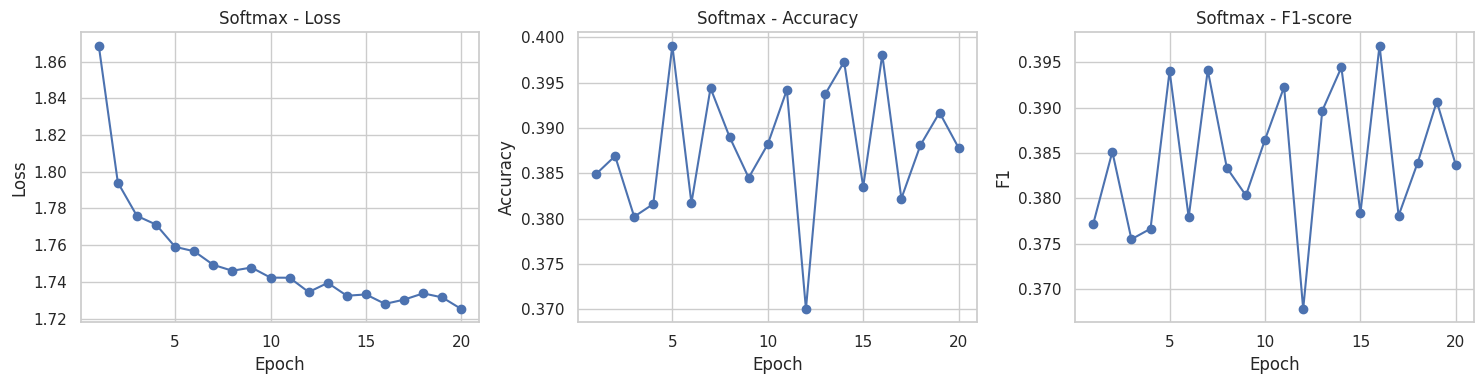

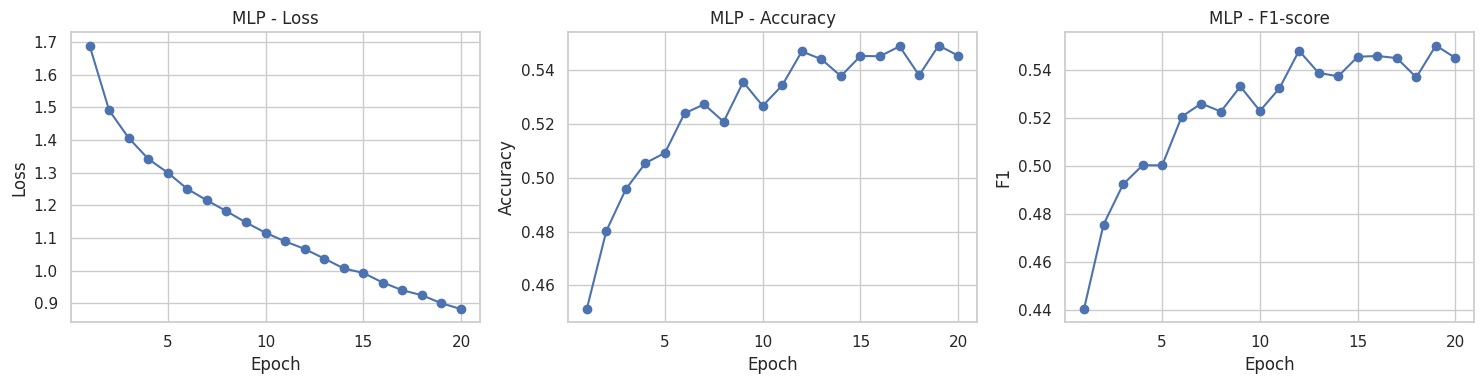

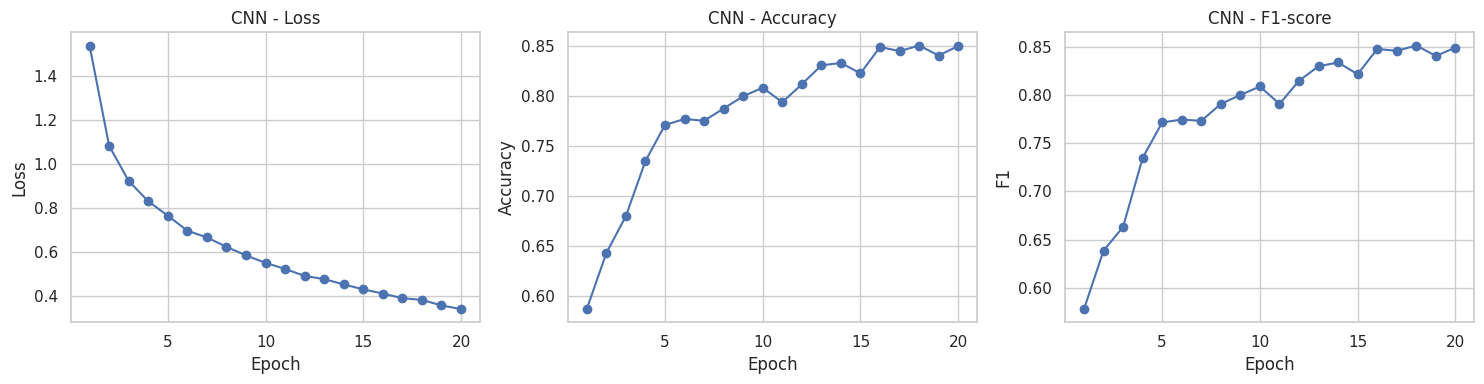

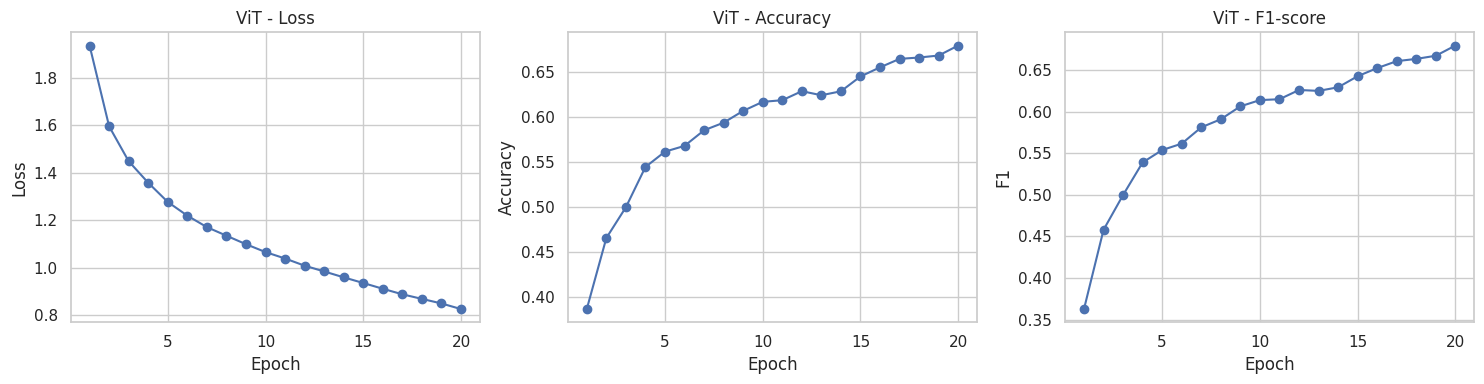

In [9]:
def plot_training_history(histories):
    for name, history in histories.items():
        epochs = range(1, len(history["loss"]) + 1)

        plt.figure(figsize=(15,4))

        # ===== Loss =====
        plt.subplot(1,3,1)
        plt.plot(epochs, history["loss"], marker='o')
        plt.title(f"{name} - Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        # ===== Accuracy =====
        plt.subplot(1,3,2)
        plt.plot(epochs, history["acc"], marker='o')
        plt.title(f"{name} - Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")

        # ===== F1 =====
        plt.subplot(1,3,3)
        plt.plot(epochs, history["f1"], marker='o')
        plt.title(f"{name} - F1-score")
        plt.xlabel("Epoch")
        plt.ylabel("F1")

        plt.tight_layout()
        plt.show()

plot_training_history(histories)

#### **Evaluation Model**


=== Model Results ===
     Model  Accuracy  Precision  Recall  F1-score
2      CNN    0.8486   0.850887  0.8486  0.847208
3      ViT    0.6780   0.680185  0.6780  0.676313
1      MLP    0.5513   0.552940  0.5513  0.550174
0  Softmax    0.3891   0.387361  0.3891  0.384475


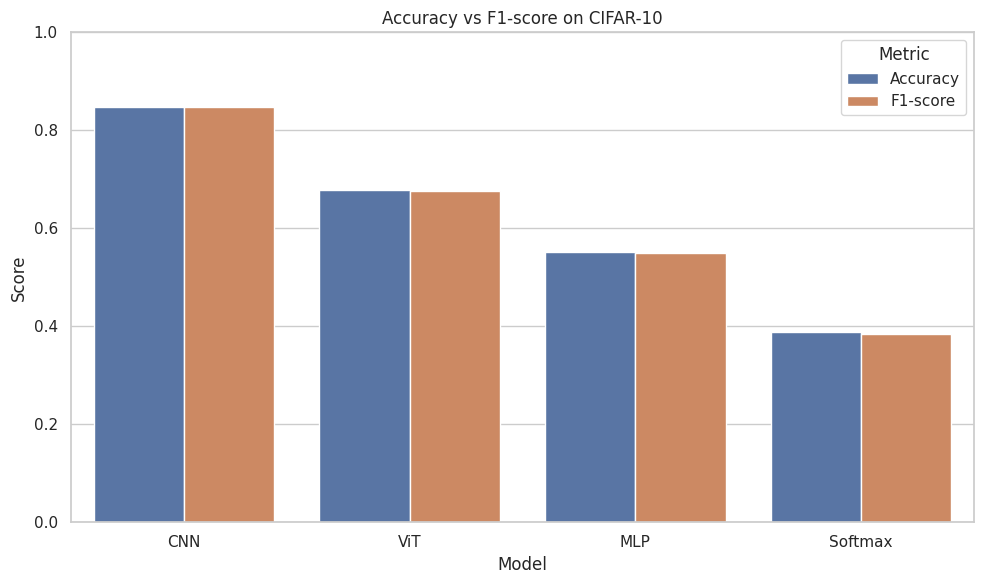

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Accuracy", ascending=False)

print("\n=== Model Results ===")
print(df_results)

df_plot = df_results[["Model", "Accuracy", "F1-score"]]

df_melt = df_plot.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure()
sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric")

plt.title("Accuracy vs F1-score on CIFAR-10")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

#### **Confusion Matrix**

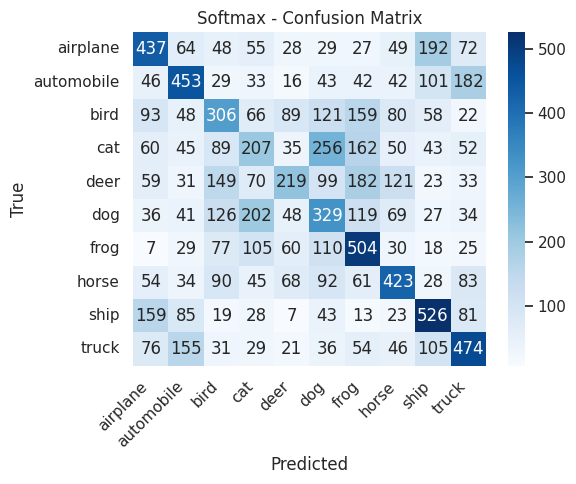

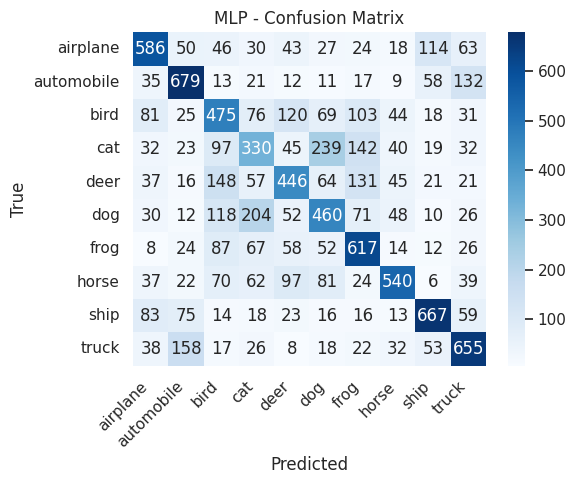

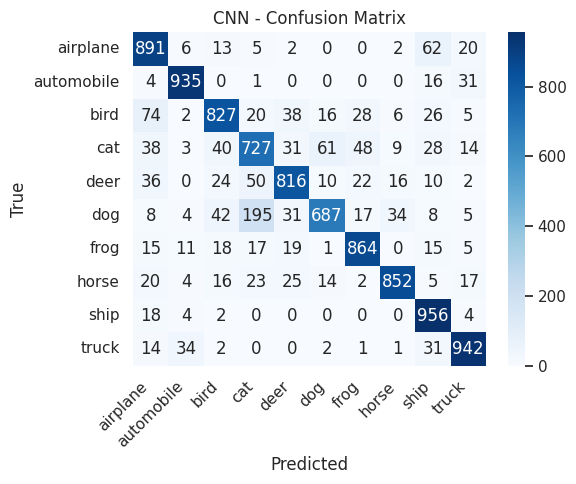

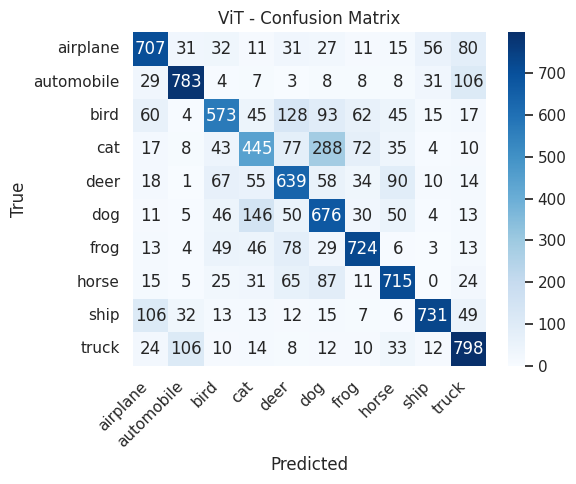

In [10]:
def plot_confusion_matrices(conf_matrices, class_names=None):
    for name, cm in conf_matrices.items():
        plt.figure(figsize=(6,5))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )

        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")

        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)


        plt.tight_layout()
        plt.show()

classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plot_confusion_matrices(conf_matrices, classes)

### **3. Comparison**

#### **Tổng quan so sánh mô hình**

Kết quả test 4 models (Accuracy & F1):
- CNN đạt hiệu năng tốt nhất (~0.85)
- ViT đứng thứ hai (~0.67-0.68)
- MLP thấp hơn (~0.55)
- Softmax (linear) kém nhất (~0.38)
Thứ tự hiệu quả: CNN > ViT > MLP > Softmax

#### **Nhận xét chi tiết từng mô hình**

**CNN (Best performer)**

- Loss giảm đều, hội tụ ổn định
- Accuracy & F1 tăng nhanh và đạt ~0.85
- Không có dấu hiệu overfitting rõ ràng

Giải thích: CNN tận dụng tốt spatial features (đặc trưng không gian) của ảnh, các lớp Conv + Pooling giúp học được: cạnh (edges), texture, object parts

Nhận xét: có thể thấy phù hợp nhất cho bài toán phân loại ảnh, đặc biệt với dataset nhỏ (CIFAR-10)

**ViT (Vision Transformer)**

- Hiệu năng khá (~0.67) nhưng thua CNN đáng kể

Nguyên nhân: ViT cần dataset lớn hoặc pretraining. Do tập CIFAR-10 nhỏ → transformer khó học tốt từ đầu.

Nhận xét: ViT không phải lúc nào cũng tốt hơn CNN, đặc biệt với dataset nhỏ

**Mult-Layer Perceptron (MLP)**

- Hiệu năng trung bình (~0.55)
- Confusion matrix cho thấy nhầm lẫn nhiều giữa các class giống nhau (cat-dog, deer-horse, ...)

Nguyên nhân:
- MLP flatten ảnh ngay từ đầu
- Mất toàn bộ cấu trúc không gian

Nhận xét: MLP model chỉ học pattern dạng vector → không phù hợp cho bài toán phân loại ảnh

**Softmax (Linear model)**

- Hiệu năng rất thấp (~0.38)
- Gần như không học được đặc trưng phức tạp

Nguyên nhân:
- Chỉ là linear classifier
- Không có: feature extraction, non-linearity

Nhận xét: mô hình tuyến tính chỉ phù hợp làm baseline